In [434]:
"""
Use the "breast cancer Wisconsin dataset" use the appropriate processing
using the logistic regression and the decision tree classifier.

Display the appropriate metices for traing and testing and confusion matrix for the testing data.
"""

'\nUse the "breast cancer Wisconsin dataset" use the appropriate processing\nusing the logistic regression and the decision tree classifier.\n\nDisplay the appropriate metices for traing and testing and confusion matrix for the testing data.\n'

In [435]:
# LOADING THE DATASET

In [436]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer(as_frame=True)

X = breast_cancer.data
y = breast_cancer.target


In [437]:
# DATA PREPROCESSING

In [438]:
df = breast_cancer.frame

In [439]:
# CHECK THE DATASET VALUES, THE SHAPE OF THE DATASET AND TEH COLUMNS INCLUDED IN THE DATASET
print("\nHEAD: ")
display(df.head())

print("\nSHAPE: ")
display(df.shape)

print("\nCOLUMNS: ")
display(df.columns.tolist())


HEAD: 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



SHAPE: 


(569, 31)


COLUMNS: 


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [440]:
# CHECK THE DATATYPES OF THE DATASET
print("\nTYPES: \n", df.dtypes)


TYPES: 
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symm

In [441]:
# SUMMARY OF THE DATSET: WHAT THE COUNT IS THE MEAN VALUE
# I HAVE DONE THIS IN ORDER TO CHECK HOW MUCH EACH VALES VARRY AS IF THE VLAUES VARRY TO MUCH IN EACH COLUMN NEED TO SCALE THE VALUE
print("STATISTICAL SUMMARY: ")
display(df.describe())

STATISTICAL SUMMARY: 


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [442]:
print("CATEGORICAL COLUMS: ")
display(df.select_dtypes(include='object').columns.tolist())

CATEGORICAL COLUMS: 


[]

In [443]:
import numpy as np

In [444]:
print("NUMERICAL COLUMS: ")
display(df.select_dtypes(include=np.number).columns.tolist())

NUMERICAL COLUMS: 


['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [445]:
import pandas as pd

In [446]:
missing = df.isnull().sum()

missing_percentage = missing / len(df) * 100

missing_table = pd.DataFrame({
    "MISSING COUNT": missing,
    "MISSING PERCENTAGE": missing_percentage
})

display(missing_table)

,MISSING COUNT,MISSING PERCENTAGE
mean radius,0,0.0
mean texture,0,0.0
mean perimeter,0,0.0
mean area,0,0.0
mean smoothness,0,0.0
mean compactness,0,0.0
mean concavity,0,0.0
mean concave points,0,0.0
mean symmetry,0,0.0
mean fractal dimension,0,0.0


In [447]:
import matplotlib.pyplot as plt

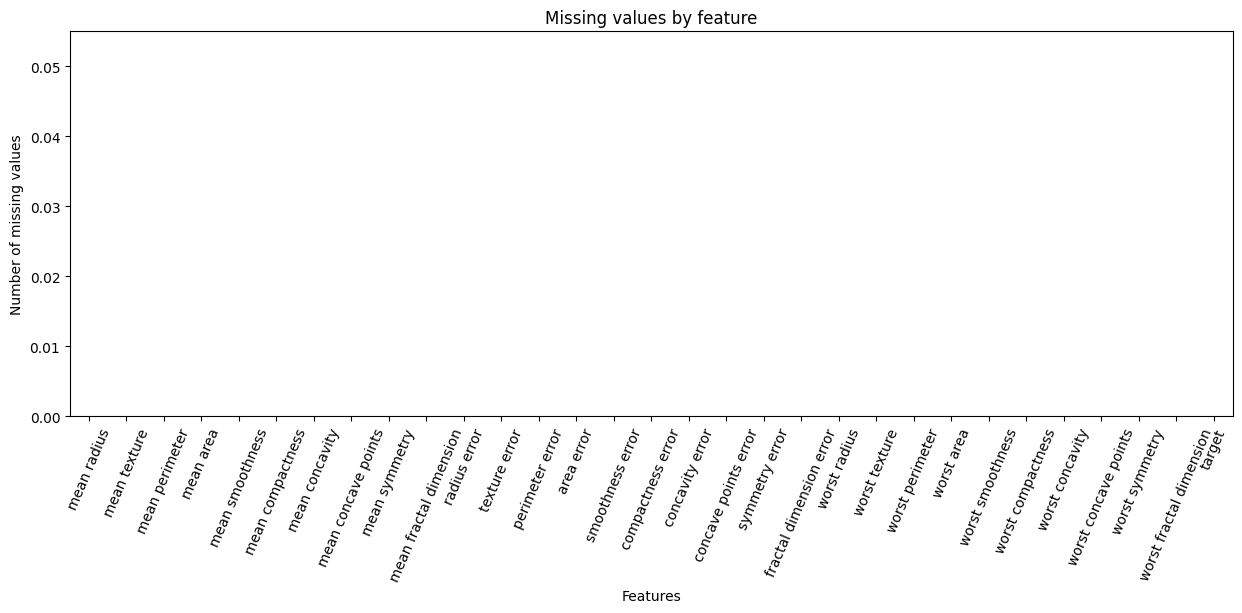

In [448]:
plt.figure(figsize=(15, 5))
missing.plot(kind='bar')

plt.title("Missing values by feature")
plt.xlabel("Features")
plt.ylabel("Number of missing values")

plt.ylim(bottom=0)
plt.xticks(rotation=67)
plt.show()

In [449]:
"""
From the above observation on the breast cancer Wisconsin dataset
1. All the columns in the dataset are "NUMERICAL COLUMNS"
2. The dataset has "NO" missing values
"""

'\nFrom the above observation on the breast cancer Wisconsin dataset\n1. All the columns in the dataset are "NUMERICAL COLUMNS"\n2. The dataset has "NO" missing values\n'

In [450]:
# MIN-MAX SCALING
# Observed that not all the colums require the min max scaling as in some of the columns already the values do not varry a lot

In [451]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
scaling_features = df[numerical_features]

In [452]:
# SPLITTING THE DATA TO TRAINING AND TESTING AND FEATURE SCALING(STANDARDSCALING)

In [453]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.fit_transform(X_test)

In [454]:
# LOGISTIC REGRESSION

In [455]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=100)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred_train = logistic_model.predict(X_train_scaled)
logistic_pred_test = logistic_model.predict(X_test_scaled)


TRAINING:
Accuracy :  0.9868131868131869
Precision:  0.9868215949054272
Recall   :  0.9868131868131869
F1 score :  0.9867969138875061

TESTING:
Accuracy :  0.9824561403508771
Precision:  0.9829367940398942
Recall   :  0.9824561403508771
F1 score :  0.9823691172375383

Confusion Matrix



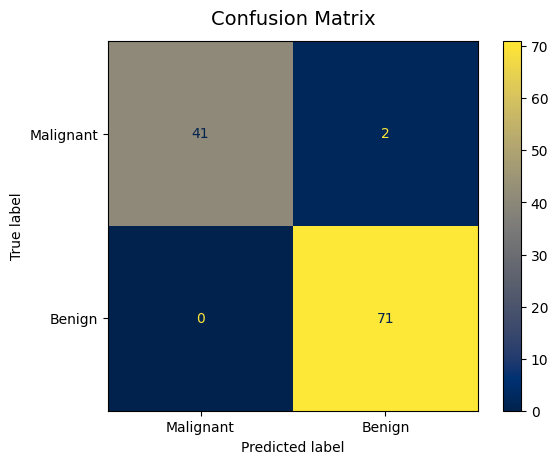

In [456]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

print("\nTRAINING:")
print("Accuracy : ", accuracy_score(y_train, logistic_pred_train))
print("Precision: ", precision_score(y_train, logistic_pred_train, average="weighted"))
print("Recall   : ", recall_score(y_train, logistic_pred_train, average="weighted"))
print("F1 score : ", f1_score(y_train, logistic_pred_train, average="weighted"))

print("\nTESTING:")
print("Accuracy : ", accuracy_score(y_test, logistic_pred_test))
print("Precision: ", precision_score(y_test, logistic_pred_test, average="weighted"))
print("Recall   : ", recall_score(y_test, logistic_pred_test, average="weighted"))
print("F1 score : ", f1_score(y_test, logistic_pred_test, average="weighted"))

print("\nConfusion Matrix\n")
logistic_cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred_test,
    display_labels=["Malignant", "Benign"],
    cmap=plt.cm.cividis
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()

In [457]:
# DECISION TREE

In [458]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree_model.fit(X_train_scaled, y_train)

decision_tree_pred_train = decision_tree_model.predict(X_train_scaled)
decision_tree_pred_test = decision_tree_model.predict(X_test_scaled)


TRAINING:
Accuracy :  0.978021978021978
Precision:  0.978021978021978
Recall   :  0.978021978021978
F1 score :  0.978021978021978

TESTING:
Accuracy :  0.9473684210526315
Precision:  0.9474739303990012
Recall   :  0.9473684210526315
F1 score :  0.947107351712615

Confusion Matrix



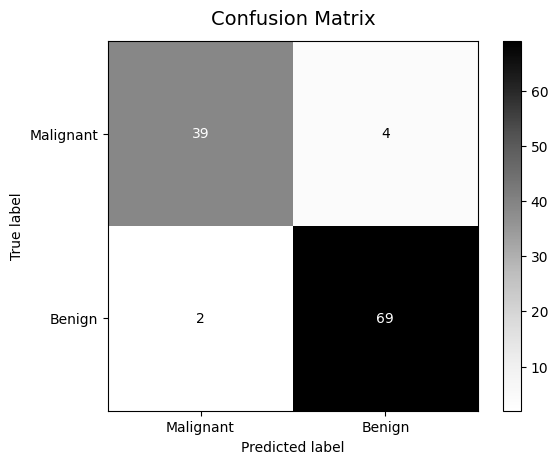

In [459]:
print("\nTRAINING:")
print("Accuracy : ", accuracy_score(y_train, decision_tree_pred_train))
print("Precision: ", precision_score(y_train, decision_tree_pred_train, average="weighted"))
print("Recall   : ", recall_score(y_train, decision_tree_pred_train, average="weighted"))
print("F1 score : ", f1_score(y_train, decision_tree_pred_train, average="weighted"))

print("\nTESTING:")
print("Accuracy : ", accuracy_score(y_test, decision_tree_pred_test))
print("Precision: ", precision_score(y_test, decision_tree_pred_test, average="weighted"))
print("Recall   : ", recall_score(y_test, decision_tree_pred_test, average="weighted"))
print("F1 score : ", f1_score(y_test, decision_tree_pred_test, average="weighted"))

print("\nConfusion Matrix\n")
logistic_cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_pred_test,
    display_labels=["Malignant", "Benign"],
    cmap=plt.cm.Greys
)
plt.title("Confusion Matrix", fontsize=14, pad=12)
plt.show()